In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as ss




## Code for Figure 6
We demonstrate the effect on the cost upon different possible input probability. One uniform input, one uniform activation, one uniform cost.


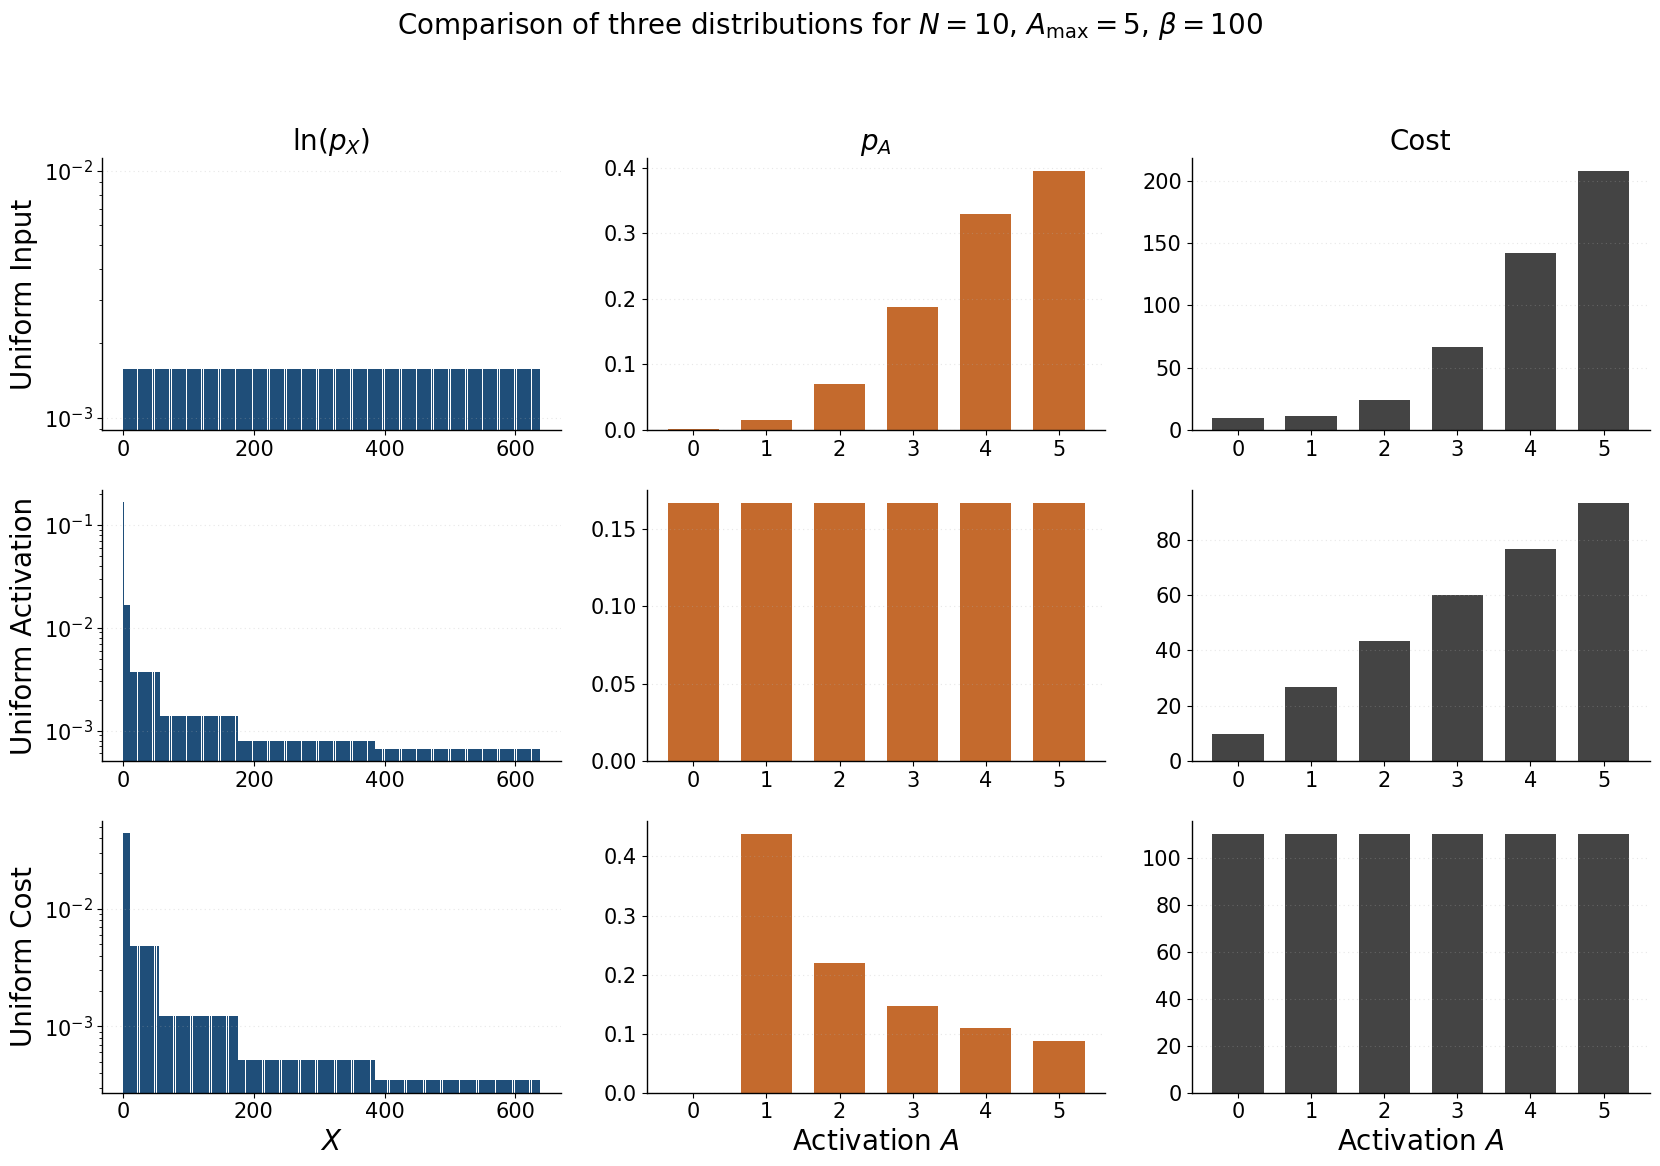

In [2]:
N_fin = 10 # numbers of neurons
A_fin = 5 # nbr of maximal activations
beta = 100 # a beta high enough to make activation cost matter

# We assume a number of codewords that perfectly match to avoid borders effects.

all_binom = np.array([ss.binom(N_fin, i) for i in range(A_fin + 1)])
X_sz = int(np.sum(all_binom))
X_points = np.arange(X_sz)

def Harmonic_number(A): # harmonic for the uniform cost
    return np.sum(1 / np.arange(1, A + 1))

H_A = Harmonic_number(A_fin)

# Possible Input 1 --> uniform input, increasing activation and close to exponential cost
p_x1 = np.ones(X_sz) / X_sz
p_a1 = np.zeros(A_fin + 1)
Cost_1 = np.zeros(A_fin + 1)

for i in range(A_fin + 1):
    p_a1[i] = all_binom[i] / X_sz # Eq 44
    Cost_1[i] = beta * (i * all_binom[i] / X_sz) + N_fin # Eq 33

# Possible Input 2 --> uniform activation and linear cost
p_x2 = np.zeros(X_sz)
p_a2 = np.ones(A_fin + 1) / (A_fin + 1) # Eq. 46
Cost_2 = np.zeros(A_fin + 1)

for i in range(A_fin + 1):
    start_index_on_x = int(np.sum(all_binom[:i])) # Eq. 47
    end_index_on_x = int(np.sum(all_binom[:i + 1]))
    p_x2[start_index_on_x:end_index_on_x] = 1 / (all_binom[i] * (A_fin + 1)) # Eq. 47
    Cost_2[i] = beta * (i / (A_fin + 1)) + N_fin # Eq 33

# Possible Input 3 --> uniform cost
p_x3 = np.zeros(X_sz)
p_a3 = np.zeros(A_fin + 1)
Cost_3 = np.zeros(A_fin + 1) + beta + N_fin

for i in range(1, A_fin + 1):  # to avoid divide by 0 so the 0 activation is not taken into account
    start_index_on_x = int(np.sum(all_binom[:i]))
    end_index_on_x = int(np.sum(all_binom[:i + 1]))
    p_x3[start_index_on_x:end_index_on_x] = 1 / (i * all_binom[i] * H_A) # Eq. 49
    p_a3[i] = 1 / (H_A * i) # Eq. 48

# -----------------------------
# Plot
# -----------------------------
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
})

color_X = "#1f4e79"  
color_A = "#c46a2d"  
color_C = "#444444"   

fig, axes = plt.subplots(3, 3, figsize=(17, 12))

# Row data
PX_list = [p_x1, p_x2, p_x3]
PA_list = [p_a1, p_a2, p_a3]
C_list  = [Cost_1, Cost_2, Cost_3]

row_titles = [
    "Uniform Input",
    "Uniform Activation",
    "Uniform Cost"
]

# -----------------------------
# Fill the 3x3 grid
# -----------------------------
for row in range(3):
    # Column 1: P_X
    px_plot = PX_list[row].copy()
    if row in [1, 2]:
        px_plot[px_plot == 0] = np.nan  # safer for log scale

    axes[row, 0].bar(X_points, px_plot, color=color_X, width=0.9)
    axes[row, 0].set_ylabel(row_titles[row])

    if row == 2:
        axes[row, 0].set_xlabel(r"$X$")
    if row == 0:
        axes[row, 0].set_title(r"$\ln(p_X)$")

    # Set log scale for rows 2 and 3 in P_X
    if row in [0,1, 2]:
        axes[row, 0].set_yscale("log")

    # Column 2: P_A
    axes[row, 1].bar(range(A_fin + 1), PA_list[row], color=color_A, width=0.7)
    if row == 2:
        axes[row, 1].set_xlabel(r"Activation $A$")
    if row == 0:
        axes[row, 1].set_title(r"$p_A$")

    # Column 3: Cost
    axes[row, 2].bar(range(A_fin + 1), C_list[row], color=color_C, width=0.7)
    if row == 2:
        axes[row, 2].set_xlabel(r"Activation $A$")
    if row == 0:
        axes[row, 2].set_title("Cost")

# -----------------------------
# Minimalist styling
# -----------------------------
for ax in axes.ravel():
    ax.grid(True, axis="y", linestyle=(0, (1, 3)), alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)

fig.suptitle(
    rf"Comparison of three distributions for $N={N_fin}$, $A_{{\max}}={A_fin}$, $\beta={beta}$",
    fontsize=20, y=0.98
)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()